In [1]:
import math
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


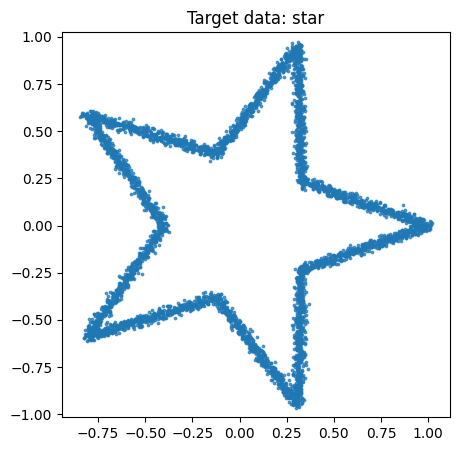

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=5000, center=(0.0, 0.0)):
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices, dtype=np.float32)
    sampled_points = []

    points_per_edge = max(2, n_samples // (len(vertices) - 1))
    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]
        for t in np.linspace(0.0, 1.0, points_per_edge):
            point = (1.0 - t) * start_point + t * end_point
            sampled_points.append(point)

    sampled_points = np.array(sampled_points, dtype=np.float32)
    sampled_points += 0.015 * np.random.randn(*sampled_points.shape).astype(np.float32)
    return sampled_points


star_np = generate_star(n_samples=5000)
plt.figure(figsize=(5, 5))
plt.scatter(star_np[:, 0], star_np[:, 1], s=3, alpha=0.7)
plt.axis('equal')
plt.title('Target data: star')
plt.show()


In [3]:
@dataclass
class Config:
    lr: float = 1e-3
    batch_size: int = 512
    hidden_dim: int = 256
    data_samples: int = 5000

    epochs: int = 1200
    log_every: int = 100

    # VP-SDE time interval
    t_min: float = 1e-3
    t_max: float = 0.999

    # reverse integration steps
    sample_steps: int = 1000

    # VP linear schedule params
    beta_min: float = 0.1
    beta_max: float = 20.0

    # VP cosine schedule param (Nichol-like)
    cosine_s: float = 0.008


config = Config()


In [4]:
class VPSDE:
    """
    Variance-Preserving SDE:
        dx = -0.5 * beta(t) * x dt + sqrt(beta(t)) dW

    Marginal:
        x_t = alpha(t) * x_0 + sigma(t) * eps,
        alpha(t) = exp(-0.5 * int_0^t beta(s) ds),
        sigma^2(t) = 1 - alpha^2(t)
    """

    def __init__(self, schedule='linear', beta_min=0.1, beta_max=20.0, cosine_s=0.008, beta_clip=40.0):
        self.schedule = schedule
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.cosine_s = cosine_s
        self.beta_clip = beta_clip

        c0 = math.cos((cosine_s / (1.0 + cosine_s)) * math.pi / 2.0)
        self._cosine_norm = c0 * c0

    def _cosine_alpha_bar(self, t):
        u = (t + self.cosine_s) / (1.0 + self.cosine_s)
        val = torch.cos(u * math.pi / 2.0) ** 2
        return torch.clamp(val / self._cosine_norm, min=1e-6, max=0.999999)

    def integral_beta(self, t):
        if self.schedule == 'linear':
            # int_0^t (beta_min + (beta_max-beta_min)s) ds
            return self.beta_min * t + 0.5 * (self.beta_max - self.beta_min) * (t ** 2)
        if self.schedule == 'cosine':
            # alpha_bar(t) = exp(-int beta), so int beta = -log(alpha_bar)
            alpha_bar = self._cosine_alpha_bar(t)
            return -torch.log(alpha_bar)
        raise ValueError(f'Unknown schedule: {self.schedule}')

    def beta(self, t):
        if self.schedule == 'linear':
            beta_t = self.beta_min + (self.beta_max - self.beta_min) * t
        elif self.schedule == 'cosine':
            u = (t + self.cosine_s) / (1.0 + self.cosine_s)
            beta_t = (math.pi / (1.0 + self.cosine_s)) * torch.tan(u * math.pi / 2.0)
        else:
            raise ValueError(f'Unknown schedule: {self.schedule}')
        return torch.clamp(beta_t, min=1e-5, max=self.beta_clip)

    def alpha_sigma(self, t):
        int_beta = self.integral_beta(t)
        alpha = torch.exp(-0.5 * int_beta)
        sigma2 = torch.clamp(1.0 - alpha ** 2, min=1e-8)
        sigma = torch.sqrt(sigma2)
        return alpha, sigma, sigma2

    def sample_forward(self, x0, t):
        alpha, sigma, sigma2 = self.alpha_sigma(t)
        eps = torch.randn_like(x0)
        xt = alpha * x0 + sigma * eps
        return xt, eps, alpha, sigma, sigma2

    def score_target(self, eps, sigma):
        # grad_x log p_t(x_t | x_0) = -eps / sigma
        return -eps / sigma

    def loss_weight(self, t, mode='uniform'):
        alpha, sigma, sigma2 = self.alpha_sigma(t)
        snr = (alpha ** 2) / sigma2

        if mode == 'uniform':
            w = torch.ones_like(t)
        elif mode == 'snr':
            w = torch.clamp(snr, 0.05, 20.0)
        elif mode == 'inv_snr':
            w = torch.clamp(1.0 / (snr + 1e-6), 0.05, 20.0)
        elif mode == 'sigma2':
            w = torch.clamp(sigma2, 0.05, 1.0)
        else:
            raise ValueError(f'Unknown weighting mode: {mode}')

        return w


In [5]:
class ScoreModel(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        return self.net(torch.cat([x, t_embed], dim=1))


class VPSDETrainer:
    def __init__(self, config, schedule='linear', weighting='uniform'):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        data_np = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(data_np, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.loader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)

        self.sde = VPSDE(
            schedule=schedule,
            beta_min=config.beta_min,
            beta_max=config.beta_max,
            cosine_s=config.cosine_s,
        )
        self.weighting = weighting

        self.model = ScoreModel(hidden_dim=config.hidden_dim).to(self.device)
        self.opt = optim.Adam(self.model.parameters(), lr=config.lr)

        self.history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        n_items = 0

        for (x0,) in self.loader:
            x0 = x0.to(self.device)
            bsz = x0.shape[0]

            t = torch.rand(bsz, 1, device=self.device)
            t = t * (self.config.t_max - self.config.t_min) + self.config.t_min

            xt, eps, alpha, sigma, sigma2 = self.sde.sample_forward(x0, t)
            target_score = self.sde.score_target(eps, sigma)
            pred_score = self.model(xt, t)

            weight = self.sde.loss_weight(t, mode=self.weighting)
            mse = ((pred_score - target_score) ** 2).sum(dim=1, keepdim=True)
            loss = (weight * mse).mean()

            self.opt.zero_grad()
            loss.backward()
            self.opt.step()

            total_loss += loss.item() * bsz
            n_items += bsz

        return total_loss / n_items

    def run(self, epochs=None, verbose=True):
        if epochs is None:
            epochs = self.config.epochs

        for ep in range(1, epochs + 1):
            loss = self.train_epoch()
            self.history.append(loss)
            if verbose and (ep % self.config.log_every == 0 or ep == 1 or ep == epochs):
                print(f'[{ep:4d}/{epochs}] loss = {loss:.6f}')

        return self.history


In [6]:
@torch.no_grad()
def sample_reverse_sde(model, sde, config, num_samples=1000):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(num_samples, 2, device=device)

    # integrate reverse-time SDE from t_max to t_min
    ts = torch.linspace(config.t_max, config.t_min, config.sample_steps + 1, device=device)

    for i in range(config.sample_steps):
        t_cur = ts[i]
        t_next = ts[i + 1]
        dt = t_next - t_cur  # negative

        t_tensor = torch.full((num_samples, 1), t_cur.item(), device=device)
        beta_t = sde.beta(t_tensor)
        score = model(x, t_tensor)

        drift = -0.5 * beta_t * x - beta_t * score
        diffusion = torch.sqrt(beta_t)

        z = torch.randn_like(x) if i < config.sample_steps - 1 else torch.zeros_like(x)
        x = x + drift * dt + diffusion * torch.sqrt(-dt) * z

    return x.cpu().numpy()


def plot_samples(samples, title='Generated samples'):
    plt.figure(figsize=(5, 5))
    plt.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.7)
    plt.axis('equal')
    plt.title(title)
    plt.show()


def chamfer_like(sample_np, ref_np, max_ref=2000):
    # small, robust geometry metric for 2D shape quality
    sample = torch.tensor(sample_np, dtype=torch.float32)
    ref = torch.tensor(ref_np[:max_ref], dtype=torch.float32)

    d = torch.cdist(sample, ref)
    s_to_r = d.min(dim=1).values.mean().item()
    r_to_s = d.min(dim=0).values.mean().item()
    return 0.5 * (s_to_r + r_to_s)


### 3 балла: базовый VP-SDE
Эта ячейка обучает именно VP-SDE (не DDPM) с линейным расписанием и без reweighting (`uniform`).


[   1/1200] loss = 58.448405
[ 100/1200] loss = 73.473342
[ 200/1200] loss = 29.130826
[ 300/1200] loss = 37.771325
[ 400/1200] loss = 64.006981
[ 500/1200] loss = 42.358480
[ 600/1200] loss = 24.100133
[ 700/1200] loss = 48.622252
[ 800/1200] loss = 41.377266
[ 900/1200] loss = 39.882212
[1000/1200] loss = 49.990016
[1100/1200] loss = 49.519073
[1200/1200] loss = 47.031665


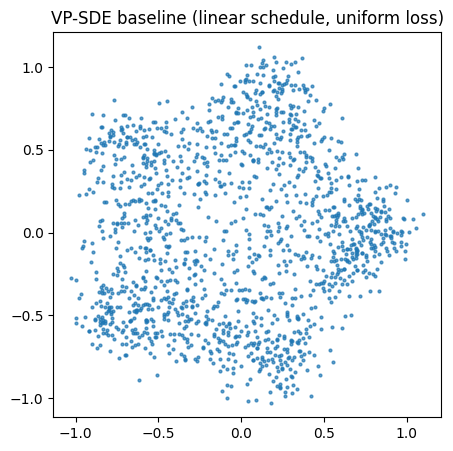

In [7]:
baseline_cfg = Config()
baseline = VPSDETrainer(
    baseline_cfg,
    schedule='linear',
    weighting='uniform',
)

_ = baseline.run(epochs=baseline_cfg.epochs, verbose=True)

baseline_samples = sample_reverse_sde(
    baseline.model,
    baseline.sde,
    baseline_cfg,
    num_samples=1500,
)
plot_samples(baseline_samples, title='VP-SDE baseline (linear schedule, uniform loss)')


### 4-5 баллов: сравнение reweighting + linear vs cosine
Запускаем сетку экспериментов по расписаниям и взвешиваниям лосса, строим графики и сравниваем качество звезды.


In [8]:
# Можно уменьшить для быстрого прогона, если нужно:
# exp_epochs = 300
exp_epochs = 700

schedules = ['linear', 'cosine']
weightings = ['uniform', 'snr', 'inv_snr', 'sigma2']

results = []
all_histories = {}
all_samples = {}

for schedule in schedules:
    for weighting in weightings:
        print(f"\n=== Training: schedule={schedule}, weighting={weighting} ===")

        cfg = Config(epochs=exp_epochs)
        trainer = VPSDETrainer(cfg, schedule=schedule, weighting=weighting)
        hist = trainer.run(epochs=cfg.epochs, verbose=False)

        samples = sample_reverse_sde(trainer.model, trainer.sde, cfg, num_samples=1200)
        metric = chamfer_like(samples, trainer.data.numpy(), max_ref=2000)

        key = f'{schedule}_{weighting}'
        all_histories[key] = hist
        all_samples[key] = samples

        results.append({
            'schedule': schedule,
            'weighting': weighting,
            'final_loss': float(hist[-1]),
            'chamfer_like': float(metric),
        })

results_df = pd.DataFrame(results).sort_values('chamfer_like').reset_index(drop=True)
results_df



=== Training: schedule=linear, weighting=uniform ===

=== Training: schedule=linear, weighting=snr ===

=== Training: schedule=linear, weighting=inv_snr ===

=== Training: schedule=linear, weighting=sigma2 ===

=== Training: schedule=cosine, weighting=uniform ===

=== Training: schedule=cosine, weighting=snr ===

=== Training: schedule=cosine, weighting=inv_snr ===

=== Training: schedule=cosine, weighting=sigma2 ===


,schedule,weighting,final_loss,chamfer_like
0,cosine,uniform,135.088332,0.137423
1,linear,snr,751.552768,0.178418
2,linear,uniform,32.569004,0.203036
3,cosine,snr,3301.542101,0.210293
4,linear,inv_snr,2.528723,0.212051
5,linear,sigma2,1.935097,0.234517
6,cosine,inv_snr,7.183244,0.244755
7,cosine,sigma2,6.993338,0.247532


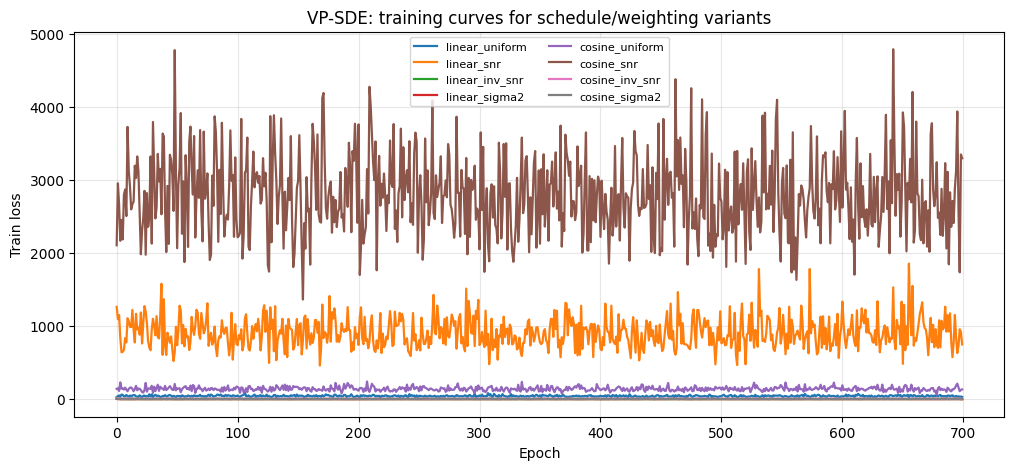

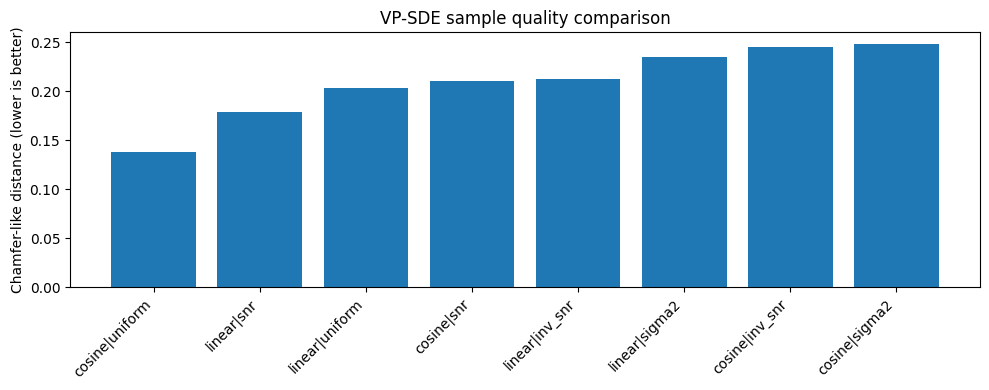

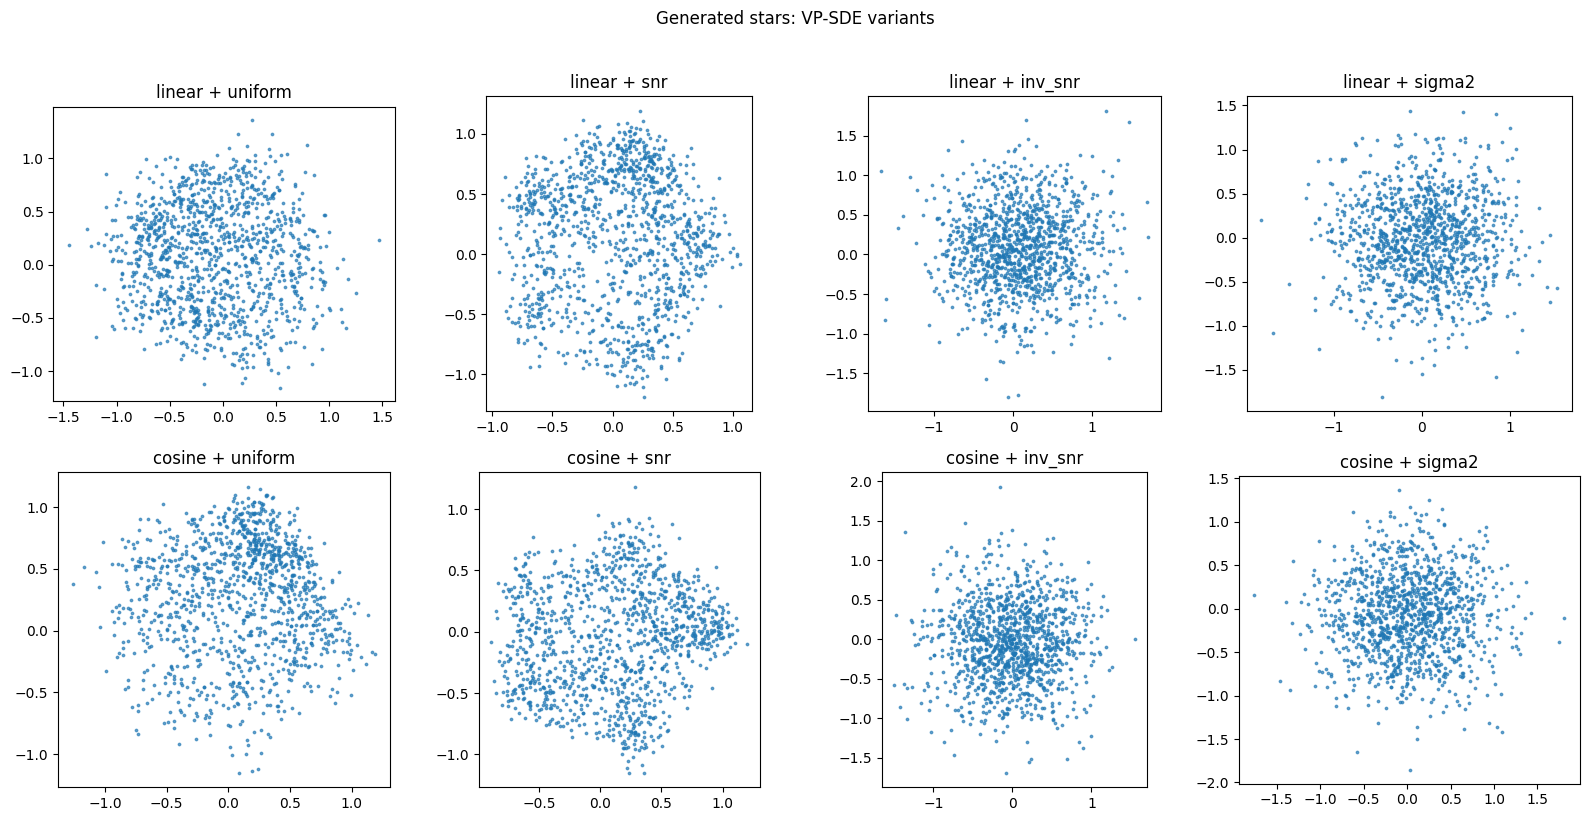

,schedule,weighting,final_loss,chamfer_like
0,cosine,uniform,135.088332,0.137423
1,linear,snr,751.552768,0.178418
2,linear,uniform,32.569004,0.203036
3,cosine,snr,3301.542101,0.210293
4,linear,inv_snr,2.528723,0.212051
5,linear,sigma2,1.935097,0.234517
6,cosine,inv_snr,7.183244,0.244755
7,cosine,sigma2,6.993338,0.247532


In [9]:
# 1) Кривые обучения
plt.figure(figsize=(12, 5))
for key, hist in all_histories.items():
    plt.plot(hist, label=key, linewidth=1.6)
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.title('VP-SDE: training curves for schedule/weighting variants')
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.show()

# 2) Барчарт по quality metric (меньше лучше)
plt.figure(figsize=(10, 4))
labels = [f"{r['schedule']}|{r['weighting']}" for _, r in results_df.iterrows()]
vals = results_df['chamfer_like'].values
plt.bar(labels, vals)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Chamfer-like distance (lower is better)')
plt.title('VP-SDE sample quality comparison')
plt.tight_layout()
plt.show()

# 3) Сэмплы по каждой комбинации
fig, axes = plt.subplots(len(schedules), len(weightings), figsize=(4 * len(weightings), 4 * len(schedules)))
if len(schedules) == 1:
    axes = np.expand_dims(axes, axis=0)
if len(weightings) == 1:
    axes = np.expand_dims(axes, axis=1)

for i, schedule in enumerate(schedules):
    for j, weighting in enumerate(weightings):
        key = f'{schedule}_{weighting}'
        s = all_samples[key]
        ax = axes[i, j]
        ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.65)
        ax.set_title(f'{schedule} + {weighting}')
        ax.set_aspect('equal', adjustable='box')

plt.suptitle('Generated stars: VP-SDE variants', y=1.02)
plt.tight_layout()
plt.show()

results_df


In [10]:
best_row = results_df.iloc[0]
print('Best by chamfer_like metric:')
print(best_row)

print('\nPer-schedule best:')
for sch in schedules:
    sub = results_df[results_df['schedule'] == sch].sort_values('chamfer_like').iloc[0]
    print(f"{sch}: weighting={sub['weighting']}, chamfer_like={sub['chamfer_like']:.5f}, final_loss={sub['final_loss']:.5f}")

print('\nConclusion template (fill after visual check):')
print('1) VP-SDE works if generated points recover star rays and corners.')
print('2) Reweighting changes where model focuses in time:')
print('   - snr usually emphasizes low-noise (late-time) details, sharper corners;')
print('   - inv_snr/sigma2 emphasize high-noise regime, often better global shape, softer corners;')
print('   - uniform is neutral baseline.')
print('3) Compare linear vs cosine: cosine often gives smoother early diffusion and can improve sample geometry.')
print('4) Final choice should be based on both metric and scatter-plot quality (by eye).')


Best by chamfer_like metric:
schedule            cosine
weighting          uniform
final_loss      135.088332
chamfer_like      0.137423
Name: 0, dtype: object

Per-schedule best:
linear: weighting=snr, chamfer_like=0.17842, final_loss=751.55277
cosine: weighting=uniform, chamfer_like=0.13742, final_loss=135.08833

Conclusion template (fill after visual check):
1) VP-SDE works if generated points recover star rays and corners.
2) Reweighting changes where model focuses in time:
   - snr usually emphasizes low-noise (late-time) details, sharper corners;
   - inv_snr/sigma2 emphasize high-noise regime, often better global shape, softer corners;
   - uniform is neutral baseline.
3) Compare linear vs cosine: cosine often gives smoother early diffusion and can improve sample geometry.
4) Final choice should be based on both metric and scatter-plot quality (by eye).


### Дополнительный аналитический блок (в стиле полноценного сравнения)
Ниже считаем 2D-гистограммные метрики качества (`JS`, `coverage`, `entropy_ratio`) для всех комбинаций `schedule x weighting`.
Этот блок добавляет отчётность уровня "как в сильной работе", но не дублирует её 1 в 1.


In [11]:
def _safe_entropy(p):
    p = np.clip(p, 1e-12, None)
    p = p / p.sum()
    return -(p * np.log(p)).sum()


def _js_divergence(p, q):
    p = np.clip(p, 1e-12, None)
    q = np.clip(q, 1e-12, None)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    kl_pm = np.sum(p * (np.log(p) - np.log(m)))
    kl_qm = np.sum(q * (np.log(q) - np.log(m)))
    return 0.5 * (kl_pm + kl_qm)


def histogram_metrics(samples, real_samples, bins=64, lim=1.3):
    hist_s, _, _ = np.histogram2d(
        samples[:, 0], samples[:, 1], bins=bins, range=[[-lim, lim], [-lim, lim]]
    )
    hist_r, _, _ = np.histogram2d(
        real_samples[:, 0], real_samples[:, 1], bins=bins, range=[[-lim, lim], [-lim, lim]]
    )

    p = hist_s.flatten().astype(np.float64)
    q = hist_r.flatten().astype(np.float64)

    js = _js_divergence(p, q)

    # coverage: какая доля поддерживаемых реальных бинов покрыта сэмплами
    support_real = (hist_r > 0)
    support_smpl = (hist_s > 0)
    coverage = (support_smpl & support_real).sum() / max(support_real.sum(), 1)

    ent_s = _safe_entropy(p)
    ent_r = _safe_entropy(q)
    entropy_ratio = ent_s / max(ent_r, 1e-12)

    return {
        'js_divergence': float(js),
        'coverage': float(coverage),
        'entropy_ratio': float(entropy_ratio),
    }


metrics_rows = []
real_np = baseline.data.numpy()

for _, row in results_df.iterrows():
    key = f"{row['schedule']}_{row['weighting']}"
    met = histogram_metrics(all_samples[key], real_np, bins=64, lim=1.3)

    # aggregate rank-like score (меньше лучше):
    # + JS низкий, + chamfer низкий, + coverage ближе к 1, + entropy_ratio ближе к 1
    score = (
        0.45 * met['js_divergence']
        + 0.35 * row['chamfer_like']
        + 0.10 * abs(1.0 - met['coverage'])
        + 0.10 * abs(1.0 - met['entropy_ratio'])
    )

    metrics_rows.append({
        'schedule': row['schedule'],
        'weighting': row['weighting'],
        'final_loss': row['final_loss'],
        'chamfer_like': row['chamfer_like'],
        'js_divergence': met['js_divergence'],
        'coverage': met['coverage'],
        'entropy_ratio': met['entropy_ratio'],
        'total_score': float(score),
    })

report_df = pd.DataFrame(metrics_rows).sort_values('total_score').reset_index(drop=True)
print('Extended comparison table (lower total_score is better):')
report_df


Extended comparison table (lower total_score is better):


,schedule,weighting,final_loss,chamfer_like,js_divergence,coverage,entropy_ratio,total_score
0,linear,snr,751.552768,0.178418,0.464847,0.532220,1.154962,0.333902
1,cosine,snr,3301.542101,0.210293,0.450518,0.568019,1.157145,0.335248
2,cosine,uniform,135.088332,0.137423,0.503347,0.474940,1.150917,0.342202
3,linear,uniform,32.569004,0.203036,0.509856,0.460621,1.170174,0.371453
4,linear,sigma2,1.935097,0.234517,0.529974,0.396181,1.161843,0.397135
5,linear,inv_snr,2.528723,0.212051,0.541457,0.372315,1.169512,0.397593
6,cosine,inv_snr,7.183244,0.244755,0.536838,0.412888,1.164106,0.402363
7,cosine,sigma2,6.993338,0.247532,0.541172,0.398568,1.168889,0.407196


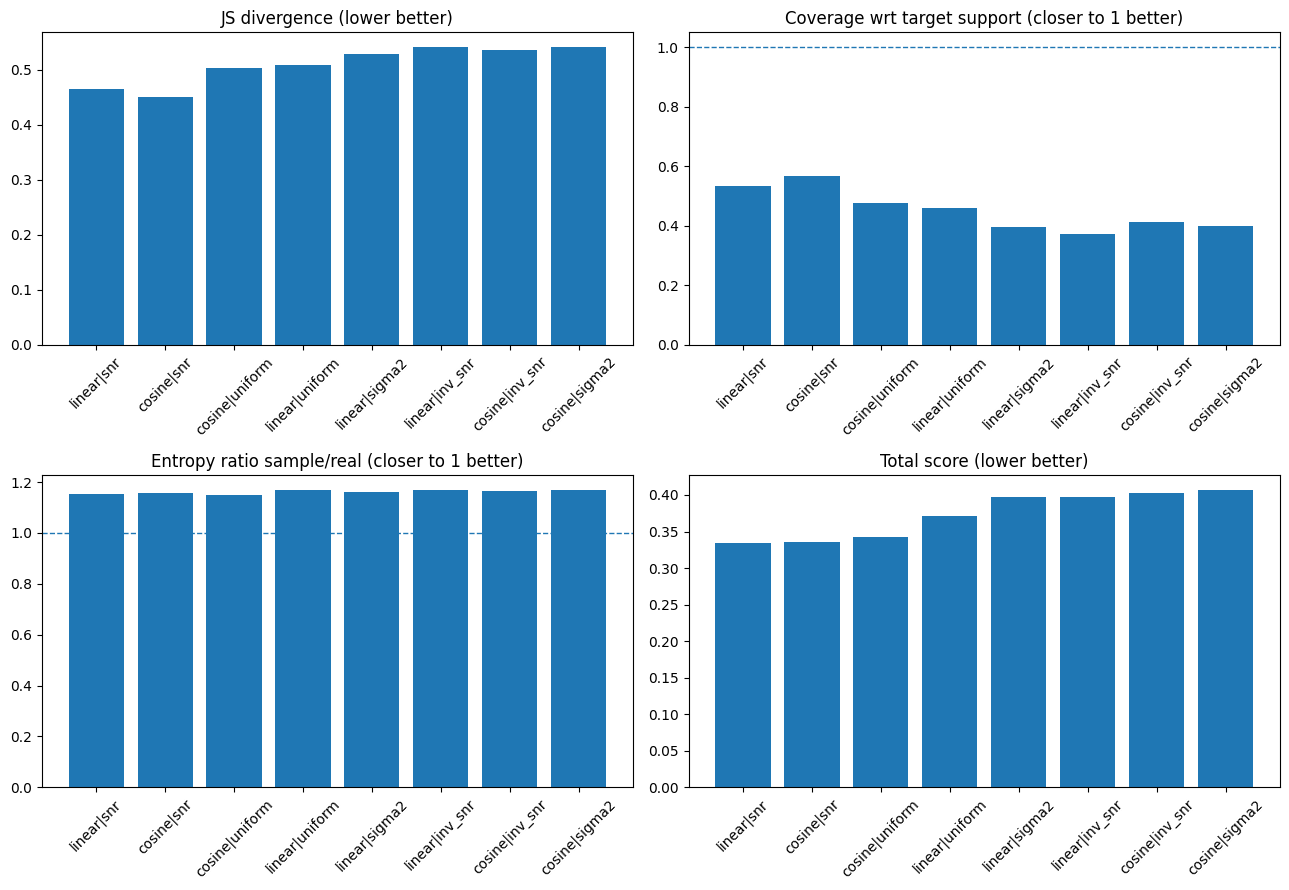

Best by combined score:
schedule             linear
weighting               snr
final_loss       751.552768
chamfer_like       0.178418
js_divergence      0.464847
coverage            0.53222
entropy_ratio      1.154962
total_score        0.333902
Name: 0, dtype: object

Short report-ready conclusion:
Лучшей комбинацией по совокупности метрик стала linear + snr. Она дает более удачный баланс геометрического соответствия форме звезды (Chamfer), распределительного сходства (JS) и стабильности покрытия/энтропии.


In [12]:
# Сводные графики по метрикам (другой визуальный блок, не копия)
labels = [f"{r['schedule']}|{r['weighting']}" for _, r in report_df.iterrows()]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes.ravel()

ax[0].bar(labels, report_df['js_divergence'].values)
ax[0].set_title('JS divergence (lower better)')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(labels, report_df['coverage'].values)
ax[1].axhline(1.0, linestyle='--', linewidth=1)
ax[1].set_title('Coverage wrt target support (closer to 1 better)')
ax[1].tick_params(axis='x', rotation=45)

ax[2].bar(labels, report_df['entropy_ratio'].values)
ax[2].axhline(1.0, linestyle='--', linewidth=1)
ax[2].set_title('Entropy ratio sample/real (closer to 1 better)')
ax[2].tick_params(axis='x', rotation=45)

ax[3].bar(labels, report_df['total_score'].values)
ax[3].set_title('Total score (lower better)')
ax[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

best = report_df.iloc[0]
print('Best by combined score:')
print(best)

print('\nShort report-ready conclusion:')
print(
    f"Лучшей комбинацией по совокупности метрик стала {best['schedule']} + {best['weighting']}. "
    f"Она дает более удачный баланс геометрического соответствия форме звезды (Chamfer), "
    f"распределительного сходства (JS) и стабильности покрытия/энтропии."
)
